In [1]:
import pandas as pd
import numpy as np
import math as mt
import matplotlib.pyplot as plt
from scipy.stats import *
import geopandas as gpd

In [2]:
path=''
france = gpd.read_file(path+"departements.geojson")
world = gpd.read_file(path+"countries.geojson")

In [3]:
data_communes = pd.read_csv(path+'RGC_2013.csv',sep=';')
data_emplois=pd.read_csv(path+'Emplois_salaries.csv',sep=';')
#Traitement préalable des données à effectuer

C:\Users\chams\AppData\Local\Temp\ipykernel_21316\3259289486.py:1: DtypeWarning: Columns (0: DEP) have mixed types. Specify dtype option on import or set low_memory=False.
  data_communes = pd.read_csv(path+'RGC_2013.csv',sep=';')
C:\Users\chams\AppData\Local\Temp\ipykernel_21316\3259289486.py:2: DtypeWarning: Columns (0: CODGEO) have mixed types. Specify dtype option on import or set low_memory=False.
  data_emplois=pd.read_csv(path+'Emplois_salaries.csv',sep=';')


In [4]:
def associate_arr_mun(num_dep,cog,num_arr_debut,num_arr_fin):
    list_arr_com=[str(num_dep)+str(num_arr).zfill(3) for num_arr in \
                  range(num_arr_debut,num_arr_fin+1)]
    mask=data_emplois['CODGEO'].str.zfill(5).isin(list_arr_com)
    data_emplois_commune=data_emplois[mask].sum()
    data_emplois_commune['CODGEO']=str(cog)
    data_emplois.loc[len(data_emplois)]=data_emplois_commune.values


In [5]:
associate_arr_mun(75,75056,101,120)
associate_arr_mun(13,13055,201,216)
associate_arr_mun(69,69123,381,389)

  CODGEO                   NOM  POPU  EFF_TOT
0  10359            SAINT-PHAL     5       96
1  10424              VILLERET     1        5
2  10436                VINETS     2      114
3  10092  CHAUFFOUR-LES-BAILLY     1       12
4  10267       NOGENT-SUR-AUBE     3       61
  CODGEO                   NOM  POPU  EFF_TOT      RATIO
0  10359            SAINT-PHAL     5       96  19.200000
1  10424              VILLERET     1        5   5.000000
2  10436                VINETS     2      114  57.000000
3  10092  CHAUFFOUR-LES-BAILLY     1       12  12.000000
4  10267       NOGENT-SUR-AUBE     3       61  20.333333
Nombre de communes  : 12843

Statistiques du ratio effectif salarié/habitant :
Moyenne : 16.8565
Médiane : 9.5455
Écart-type : 23.4498
Q1 (25e percentile) : 5.0000
Q3 (75e percentile) : 20.0000

Commune avec le ratio le plus élevé : POUPRY
Ratio : 664.0000


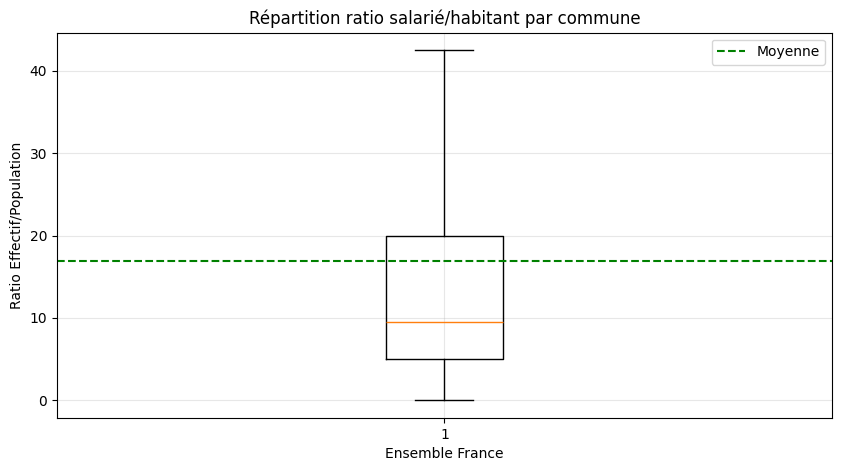

In [6]:
#Question 3.2
# Fusion des données communes et emplois
data_communes_copy = data_communes.copy()
data_communes_copy["CODGEO"] = data_communes_copy["DEP"].astype(str).str.zfill(2) + data_communes_copy["COM"].astype(str).str.zfill(3)

fusion = pd.merge(data_communes_copy, data_emplois, left_on="CODGEO", right_on="CODGEO", how="inner")
tri = fusion[["CODGEO","NOM","POPU","EFF_TOT"]].copy()
print(tri.head())

# Calcul du ratio effectif salarié par habitant
tri["RATIO"] = tri["EFF_TOT"] / tri["POPU"]
print(tri.head())

# Nettoyage des données : supprimer populations nulles et ratios NaN
tri_clean = tri[(tri["POPU"] > 0) & (tri["RATIO"].notna())].copy()

print(f"Nombre de communes  : {len(tri_clean)}")
print(f"\nStatistiques du ratio effectif salarié/habitant :")
print(f"Moyenne : {tri_clean['RATIO'].mean():.4f}")
print(f"Médiane : {tri_clean['RATIO'].median():.4f}")
print(f"Écart-type : {tri_clean['RATIO'].std():.4f}")
print(f"Q1 (25e percentile) : {tri_clean['RATIO'].quantile(0.25):.4f}")
print(f"Q3 (75e percentile) : {tri_clean['RATIO'].quantile(0.75):.4f}")

# Trouver la commune avec le ratio le plus élevé
commune_max_ratio = tri_clean.loc[tri_clean["RATIO"].idxmax()]
print(f"\nCommune avec le ratio le plus élevé : {commune_max_ratio['NOM']}")
print(f"Ratio : {commune_max_ratio['RATIO']:.4f}")

# Tracer le boxplot
plt.figure(figsize=(10, 5))
plt.boxplot(tri_clean["RATIO"], showfliers=False)
plt.axhline(tri_clean["RATIO"].mean(), color='green', linestyle='--', label='Moyenne')
plt.legend()
plt.ylabel('Ratio Effectif/Population')
plt.xlabel("Ensemble France")
plt.title('Répartition ratio salarié/habitant par commune')
plt.grid(True, alpha=0.3)
plt.show()

15.893606629311279


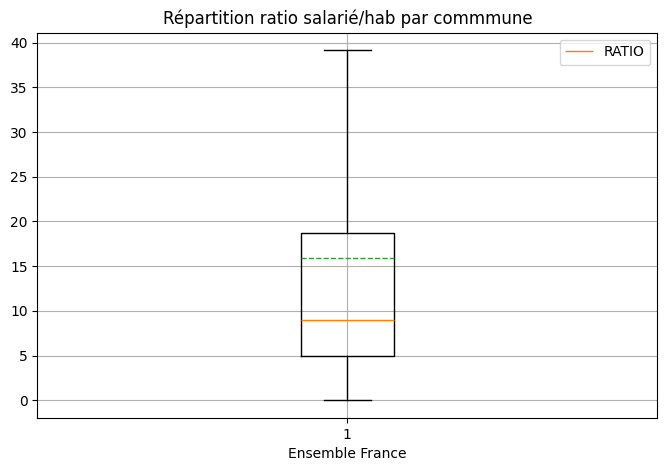

In [7]:
#print(data_communes.info())
data_communes["CODGEO"]  = data_communes["DEP"].astype(str) + data_communes["COM"].astype(str).str.zfill(3)
#print(data_communes.head())
tab1 = data_emplois["CODGEO"]
fusion = pd.merge(data_communes,data_emplois,left_on="CODGEO",right_on = "CODGEO", how = "inner")
#print(fusion.columns)

select = fusion[["CODGEO","NOM","EFF_TOT","POPU","SURFACE"]]


select["RATIO"] = select["EFF_TOT"] /select["POPU"]
tri_clean = select[(select["RATIO"].notna() & select["POPU"]>0)  ]


moyen_ration = tri_clean["RATIO"].mean()
print(moyen_ration)
#print(select["RATIO"])
plt.figure(figsize=(8,5))
plt.boxplot(tri_clean["RATIO"],showfliers=False,label="RATIO",showmeans=True, meanline=True)
plt.title("Répartition ratio salarié/hab par commmune")
plt.xlabel("Ensemble France")
plt.grid()
plt.legend()
plt.show()


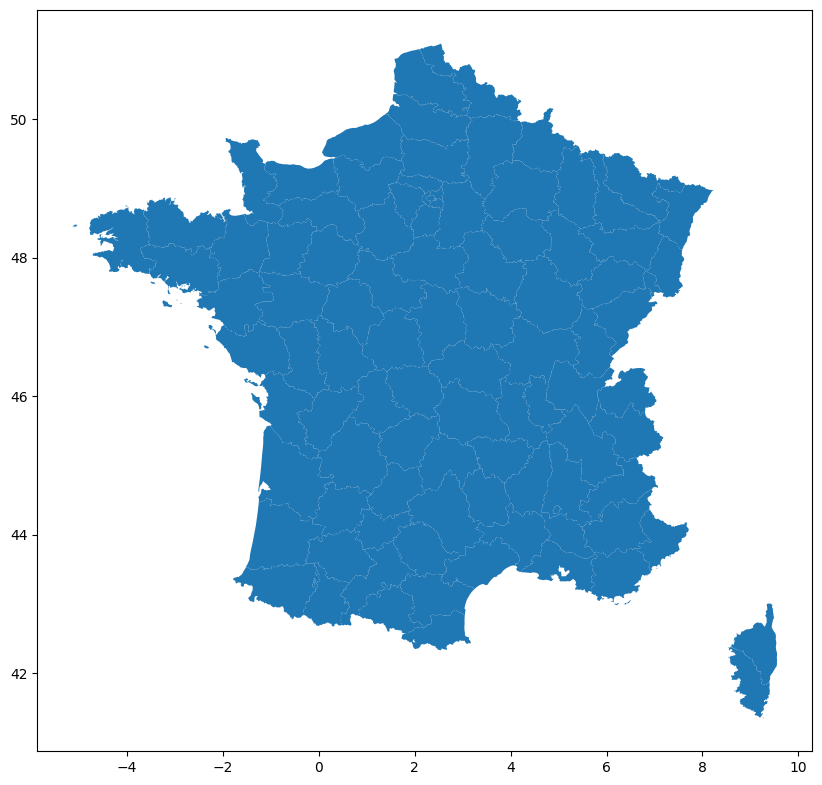

In [8]:
world = gpd.read_file("departements.geojson")
fig ,ax = plt.subplots(1,figsize=(10,10))
world_map = gpd.GeoDataFrame(world)
world_map.plot(ax=ax)
"""ax.set_xlim(-5,10)
ax.set_ylim(42,52)"""
plt.show()

<class 'pandas.Series'>
RangeIndex: 36552 entries, 0 to 36551
Series name: DENS
Non-Null Count  Dtype  
--------------  -----  
36552 non-null  float64
dtypes: float64(1)
memory usage: 285.7 KB
<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 36552 entries, 0 to 36551
Data columns (total 25 columns):
 #   Column     Non-Null Count  Dtype   
---  ------     --------------  -----   
 0   code       36552 non-null  str     
 1   nom        36552 non-null  str     
 2   geometry   36552 non-null  geometry
 3   DEP        36552 non-null  str     
 4   COM        36552 non-null  int64   
 5   ARRD       36552 non-null  int64   
 6   CANT       36552 non-null  int64   
 7   ADMI       36552 non-null  int64   
 8   POPU       36552 non-null  int64   
 9   SURFACE    36552 non-null  int64   
 10  NOM        36552 non-null  str     
 11  XLAMB2     36552 non-null  int64   
 12  YLAMB2     36552 non-null  int64   
 13  XLAMBZ     36552 non-null  int64   
 14  YLAMBZ     36552 non-null  i

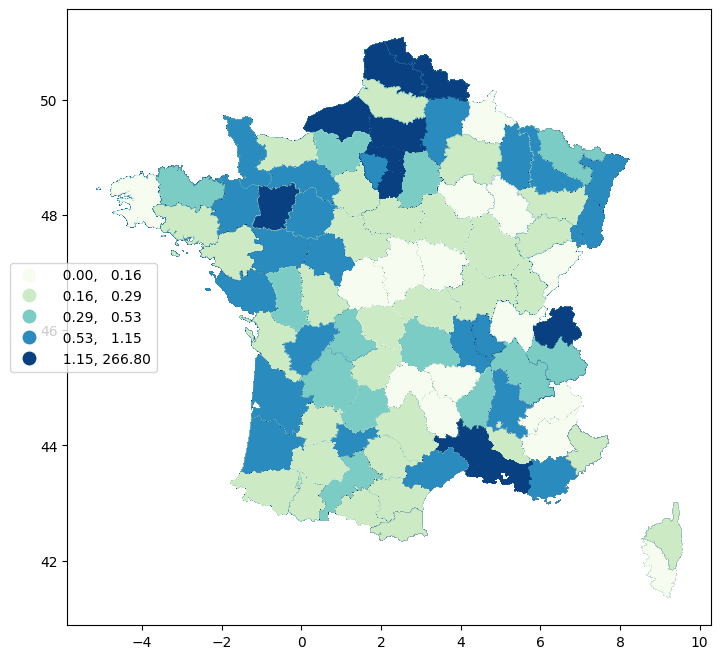

In [12]:

france_den = world.copy()
commune = data_communes.copy()

commune["DEP"] = commune["DEP"].astype(str).str.zfill(2)

france_map = pd.merge(france_den,commune,left_on="code",right_on="DEP",how= "inner")

france_map["DENS"]= france_map["POPU"] /france_map["SURFACE"] *100
france_map["DENS"].info()
france_maps = gpd.GeoDataFrame(france_map)
fig ,ax = plt.subplots(1,figsize=(9,8))
france_maps.plot(ax=ax,column='DENS',cmap="GnBu",k=5,legend=True,scheme='quantiles',legend_kwds={
    'loc': 'center left',
    'bbox_to_anchor':(-0.1,0.5)
})
print(france_map.info())
print(france.info())

Expliquer ici la différence entre moyenne et médiane. Par ailleurs quel indicateur statistique pourrait-on utiliser pour quantifier la dispersion des données ?

In [ ]:
#Question 3.3

In [ ]:
#calculs à effectuer pour rajouter la densité de population (DENS) par département


In [ ]:
#Carte densité par départements
france_map =#jointure à effectuer
print('type dataframe jointure : ',type(france_map))
france_map = gpd.GeoDataFrame(france_map)
fig, ax = plt.subplots(1, figsize=(9,8))
# On crée 5 catégories en utilisant des quantiles (la notion de quantiles est un terme générique, avec 4 catégories on subdivise les quantiles sont des quartiles et avec 10 catégories les quantiles sont des déciles)
france_map.plot(ax=ax, 
                column='DENS', 
                cmap='GnBu', #https://matplotlib.org/stable/tutorials/colors/colormaps.html  YlOrRd
                scheme='quantiles', 
                k=5, 
                legend=True,legend_kwds={'loc':'center left','bbox_to_anchor':(-0.1, 0.5)})

ax.axis('off')
plt.title("Densité population par département", fontsize=15)
ax.annotate('Année: 2013', xy=(0.1, .15), 
                                   xycoords='figure fraction', 
                                   horizontalalignment='left', 
                                   verticalalignment='top', 
                                   fontsize=12, 
                                   color='#555555')
plt.show()

SyntaxError: invalid syntax (1219499207.py, line 2)

Interpréter précisément ici la signification des données représentées sur les départements avec la teinte la plus claire

In [ ]:
#Cartes avec qqs communes

fig, ax = plt.subplots(1, figsize=(10,10))
world_map = gpd.GeoDataFrame(world)
world_map.plot(ax=ax)
geom_points=gpd.points_from_xy(data_communes.LONGI_DMS/10000, data_communes.LATI_DMS/10000)
gdf = gpd.GeoDataFrame(data_communes, geometry=geom_points)
#gdf_pcpx=Ne garder ici que les 7 villes les plus peuplées


ax.set_xlim(-5, 10)
ax.set_ylim(42, 52)

gdf_pcpx.plot(ax=ax,markersize=.......,color='r',edgecolor='black')

for x, y, label in zip(gdf_pcpx.geometry.x, gdf_pcpx.geometry.y, gdf_pcpx.NOM):
    ax.annotate(label, xy=(x, y), xytext=(3, 3), textcoords="offset points")
plt.show()
